# STAT207 Mini-Project #2 - Modeling Video Game Review Scores with Regression


- Tan

#### Imports:

In [528]:
#Imports here
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()                              # 'seaborn.set()' is 'deprecated' 
import numpy as np                     # imports the numpy package and calls it 'np'
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 1. Introduction

The video game industry is a dynamic and competitive market where understanding what drives critical acclaim is essential for developers and publishers. This report explores how gameplay length and release timing influence review scores across a wide range of titles.

### Primary Research Goal of Analysis: [Prediction]:

**Build a predictive model that will effectively predict video game review score *(`Metrics.Review Score`)* for new datasets.**

Five Chosen Explanatory Variables:
* `Length.All PlayStyles.Average`: The mean time that players reported completing the game in any way, in hours. This is the average over all the other categories.

* `Length.All PlayStyles.Median`: The median time that players reported completing the game in any way, in hours. This is the median over all the other categories.

* `Length.All PlayStyles.Rushed`: The fastest time that players reported completing the game in any way, in hours. This is the maximum over all the other categories.

* `Length.Main Story.Rushed`: The fastest time that players reported completing the main game storyline, in hours.

* `Release.Year`: The year that this game was released. 

### Secondary Research Goal of Analysis: [Interpretation]:

**Ideally, we would like for our chosen model to also yield reliable interpretative insights about the nature of the relationship between the variables in the dataset**

### Research Motivation:

In the gaming industry, understanding what influences a game’s critical success is key to designing titles that stand out in a competitive market. Building a predictive model that forecasts review scores based on game length characteristics and release timing can help *developers* and *publishers* estimate a game's reception before it hits the market. Such insights are valuable for balancing content depth and pacing to meet player expectations. *Game designers* can use this model to predict player feedback early in the development process, helping them improve their game’s chances of receiving positive reviews—ultimately boosting awareness, credibility, and sales.



## 2. Dataset Discussion

### Data Source:
This dataset was originally collected by Dr. Joe Cox and contains information on sales and playtime for over a thousand video games released between 2004 and 2010. The playtime data was crowd-sourced from "How Long to Beat." The dataset was obtained from Dr. Ellison on September 8, 2023.

Source Link: Video Games CSV File, https://corgis-edu.github.io/corgis/csv/video_games/

More information: [What makes a blockbuster video game? an empirical analysis of US sales data](https://researchportal.port.ac.uk/en/publications/what-makes-a-blockbuster-video-game-an-empirical-analysis-of-us-s)

The observations encompass metadata such as *game title*, *publisher*, *genre*, *release year*, *release console*, *review scores*, and *playtime statistics*. Playtime data was crowd-sourced from the website **“How Long to Beat”**, where users self-report completion times, while sales and other metadata were compiled from publicly available sources. However, the dataset is not fully inclusive of all possible games, as it focuses on games released between 2004 and 2010, which means newer or older games are excluded. In addition, this site only includes **Single-Player PC/Console Games**, meaning that this study is not applicable to other games such as online games, multiplayer games, etc. Due to the lack of more up-to-date game data may affect stakeholders' interpretation of the relationship between ratings and sales. Insights gained from this dataset *may not be fully applicable to current industry conditions*.

In [529]:
df = pd.read_csv("video_games.csv", keep_default_na=False)
df.head(5)

,Title,Features.Handheld?,Features.Max Players,Features.Multiplatform?,Features.Online?,Metadata.Genres,Metadata.Licensed?,Metadata.Publishers,Metadata.Sequel?,Metrics.Review Score,...,Length.Main + Extras.Average,Length.Main + Extras.Leisure,Length.Main + Extras.Median,Length.Main + Extras.Polled,Length.Main + Extras.Rushed,Length.Main Story.Average,Length.Main Story.Leisure,Length.Main Story.Median,Length.Main Story.Polled,Length.Main Story.Rushed
0,Super Mario 64 DS,True,1,True,True,Action,True,Nintendo,True,85,...,24.916667,29.966667,25.000000,16,18.333333,14.333333,18.316667,14.500000,21,9.700000
1,Lumines: Puzzle Fusion,True,1,True,True,Strategy,True,Ubisoft,True,89,...,9.750000,9.866667,9.750000,2,9.616667,10.333333,11.083333,10.000000,3,9.583333
2,WarioWare Touched!,True,2,True,True,"Action,Racing / Driving,Sports",True,Nintendo,True,81,...,3.850000,5.666667,3.333333,11,2.783333,1.916667,2.933333,1.833333,30,1.433333
3,Hot Shots Golf: Open Tee,True,1,True,True,Sports,True,Sony,True,81,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0,0.000000
4,Spider-Man 2,True,1,True,True,Action,True,Activision,True,61,...,12.766667,17.316667,12.500000,12,10.483333,8.350000,11.083333,8.000000,23,5.333333


In [530]:
original_row_num = df.shape[0]
original_row_num

1212

## 3. Dataset Cleaning

1. Only the relevant variables needed for prediction were selected: *`Length.All PlayStyles.Average`, `Length.All PlayStyles.Median`, `Length.All PlayStyles.Rushed`, `Length.Main Story.Rushed`, `Release.Year`*, and the target variable,*`Metrics.Review Score`*.

2. Drop the missing values. 

3. Outlier Cleaning. To visually inspect the relationships between variables and identify any extreme outliers, a pairplot was created. Based on this exploration, several outlier thresholds were applied. Specifically, games were filtered out if: 
* `Length.Main Story.Rushed` was greater than 60 hours,

* `Length.All PlayStyles.Rushed` was greater than 100 hours,

* `Length.All PlayStyles.Median` was greater than 100 hours,

* `Length.All PlayStyles.Average` was greater than 250 hours.

In [531]:
df = df[["Length.All PlayStyles.Average", "Length.All PlayStyles.Median", "Length.All PlayStyles.Rushed", "Length.Main Story.Rushed", "Release.Year","Metrics.Review Score"]]
df = df.dropna()
df

,Length.All PlayStyles.Average,Length.All PlayStyles.Median,Length.All PlayStyles.Rushed,Length.Main Story.Rushed,Release.Year,Metrics.Review Score
0,22.716667,24.483333,14.300000,9.700000,2004,85
1,10.100000,10.000000,9.516667,9.583333,2004,89
2,4.566667,2.500000,2.266667,1.433333,2004,81
3,0.000000,0.000000,0.000000,0.000000,2004,81
4,13.250000,10.000000,7.066667,5.333333,2004,61
...,...,...,...,...,...,...
1207,10.083333,9.333333,7.300000,6.816667,2008,71
1208,0.000000,0.000000,0.000000,0.000000,2008,62
1209,0.000000,0.000000,0.000000,0.000000,2008,51
1210,10.083333,9.333333,7.300000,6.816667,2008,64


In [532]:
df.dtypes

Length.All PlayStyles.Average    float64
Length.All PlayStyles.Median     float64
Length.All PlayStyles.Rushed     float64
Length.Main Story.Rushed         float64
Release.Year                       int64
Metrics.Review Score               int64
dtype: object

In [533]:
df.describe()

,Length.All PlayStyles.Average,Length.All PlayStyles.Median,Length.All PlayStyles.Rushed,Length.Main Story.Rushed,Release.Year,Metrics.Review Score
count,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,13.653177,11.225371,9.396163,6.974697,2006.820132,68.828383
std,19.397156,13.493717,11.176371,7.964522,1.050653,12.956266
min,0.000000,0.000000,0.000000,0.000000,2004.000000,19.000000
25%,3.562500,3.025000,2.600000,0.000000,2006.000000,60.000000
50%,8.858333,8.000000,6.708333,5.341667,2007.000000,70.000000
75%,16.033333,13.783333,11.366667,9.312500,2008.000000,79.000000
max,279.733333,126.000000,120.200000,70.000000,2008.000000,98.000000


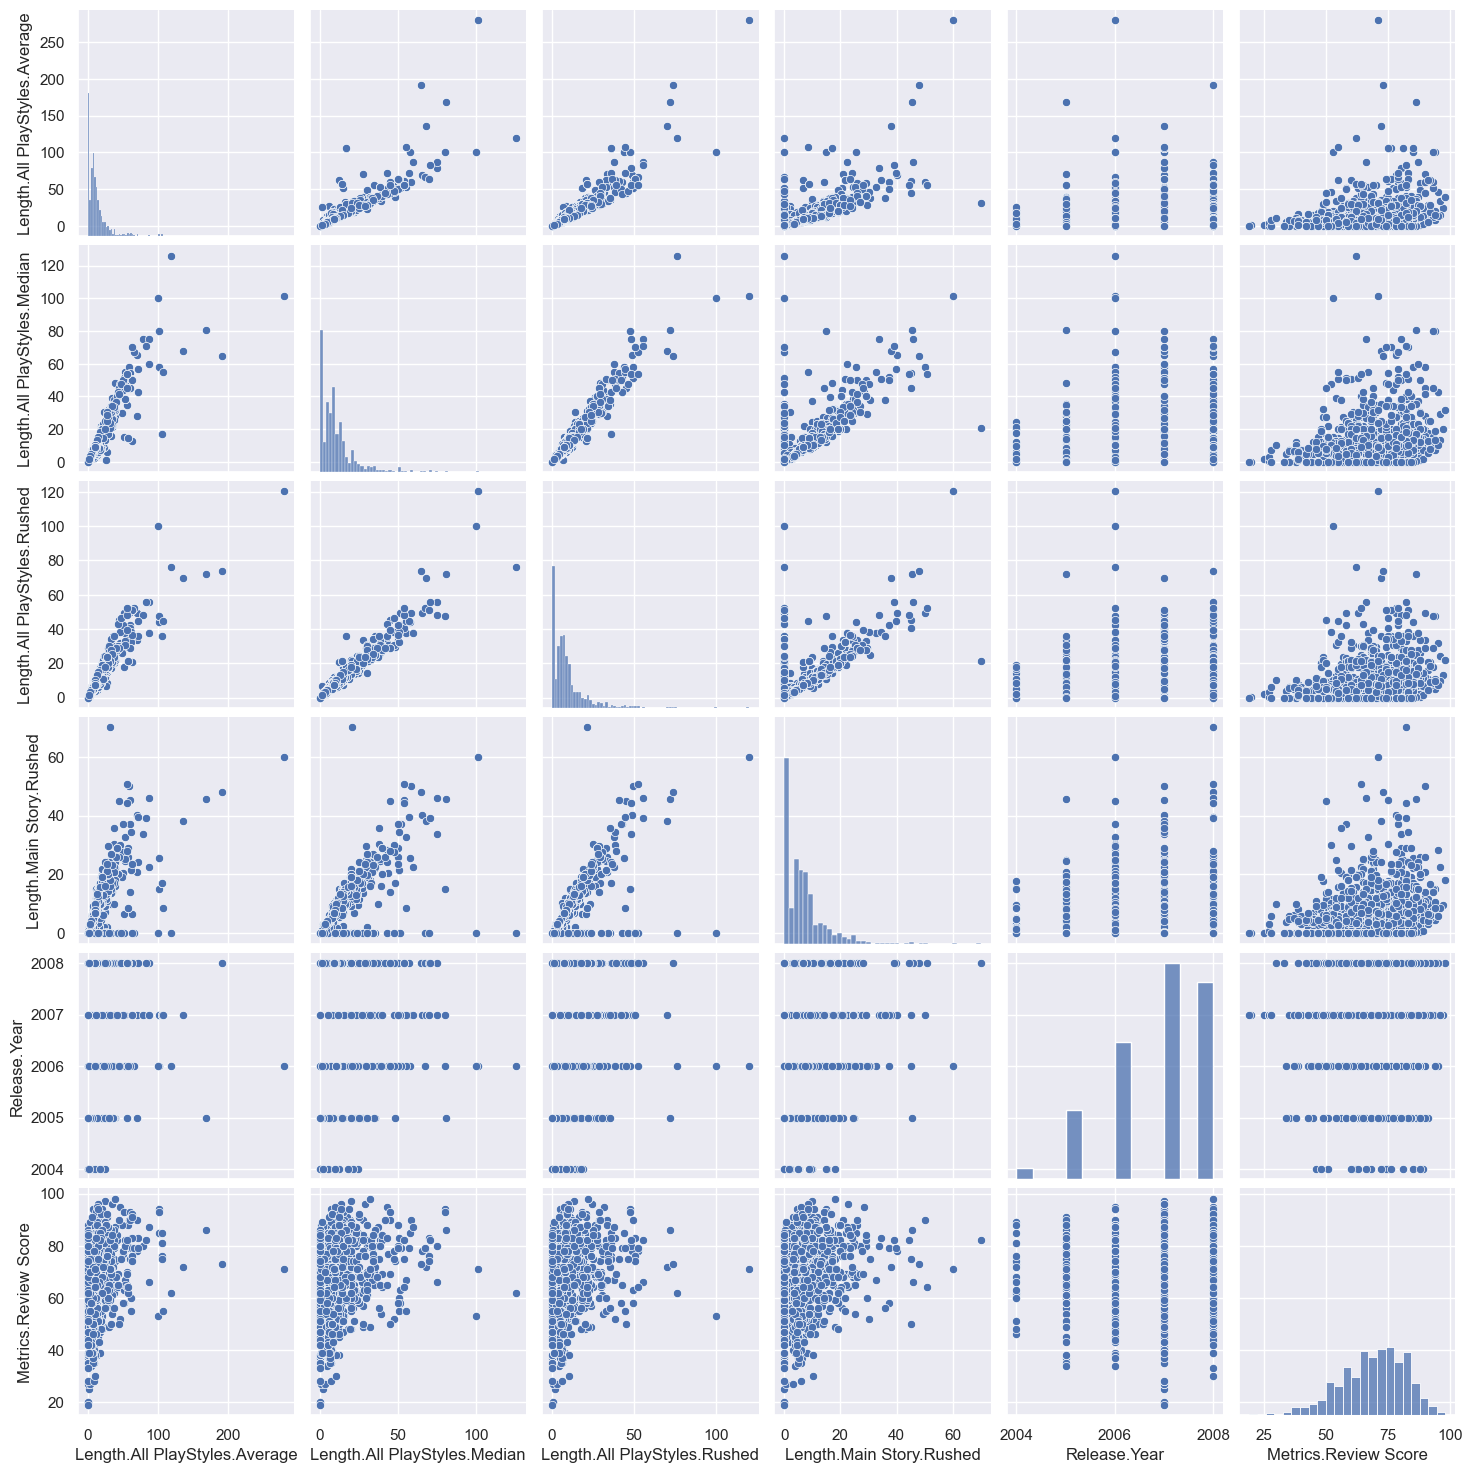

In [534]:
sns.pairplot(df)
plt.show()

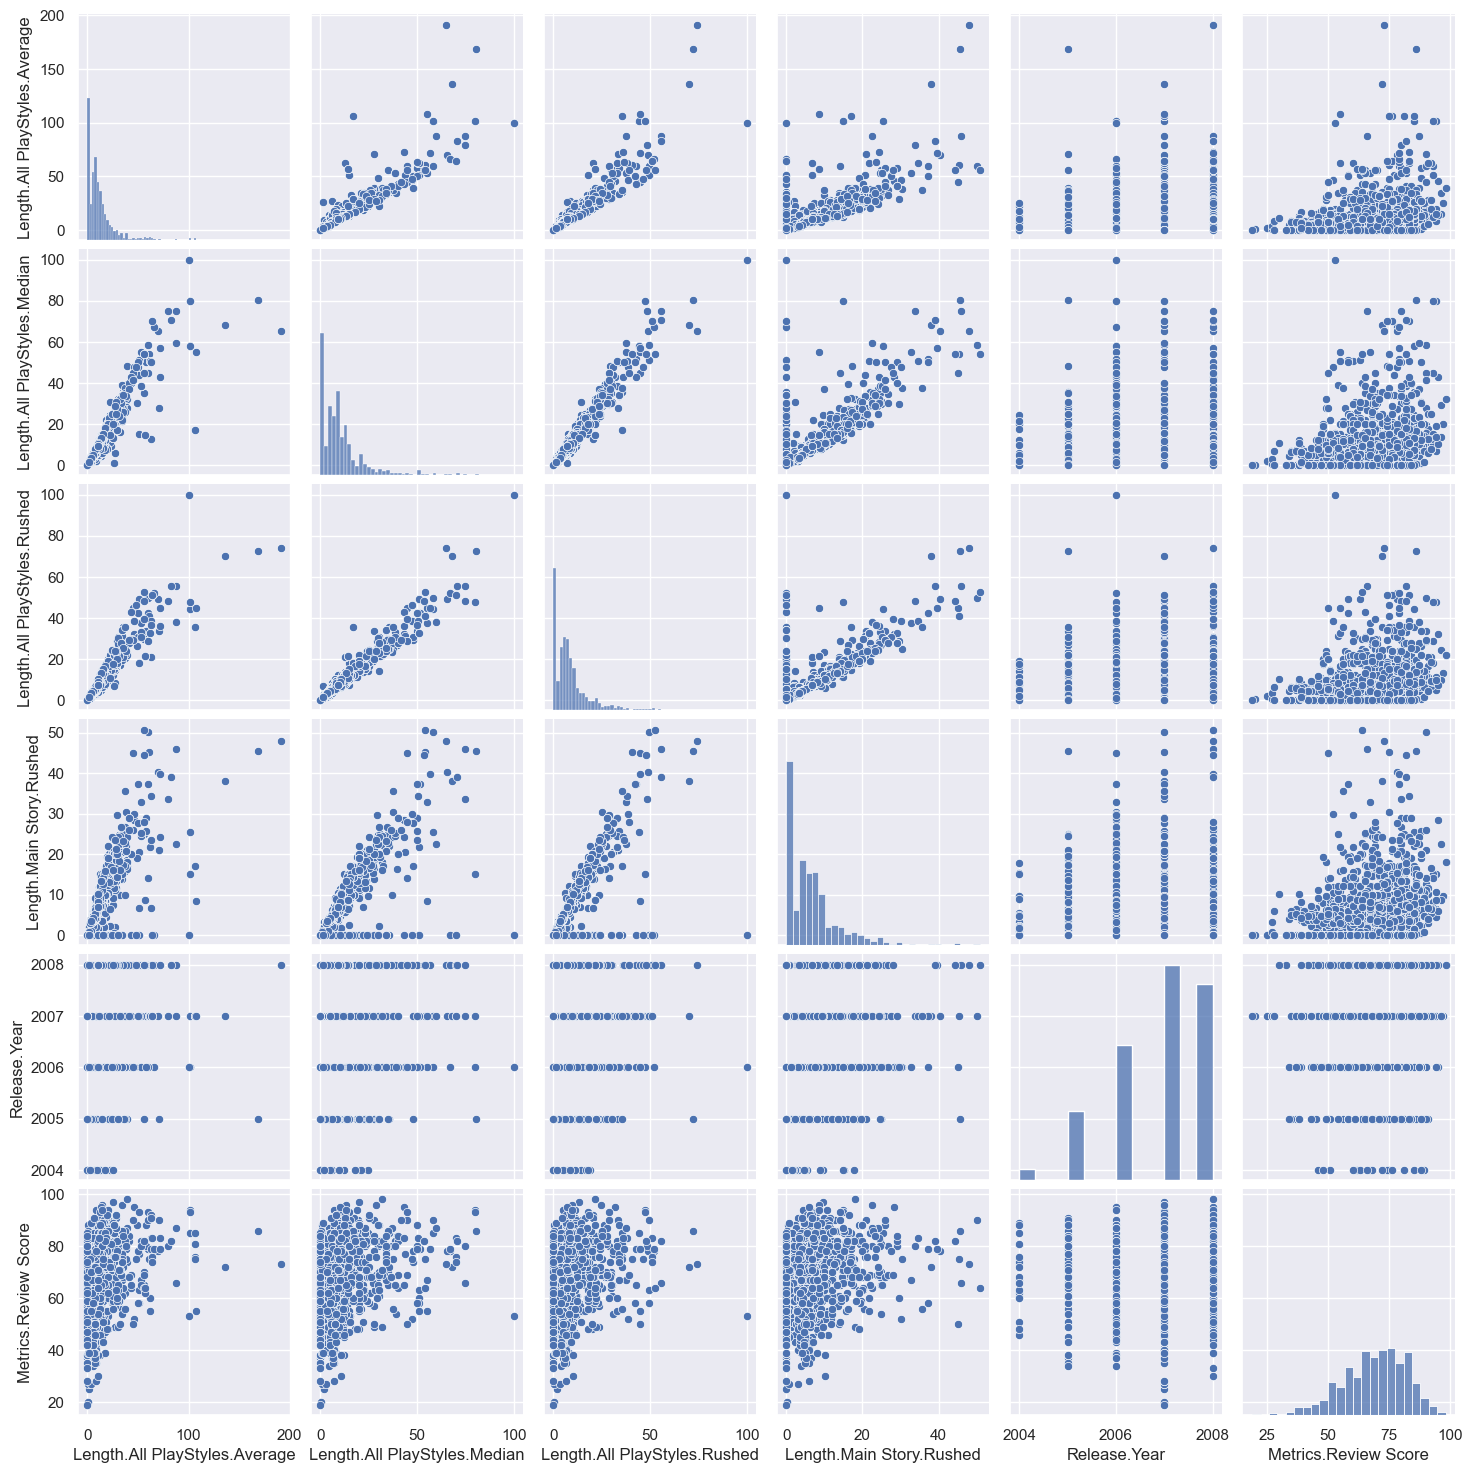

In [535]:
df = df[
    (df['Length.Main Story.Rushed'] <= 60) &
    (df['Length.All PlayStyles.Rushed'] <= 100) &
    (df['Length.All PlayStyles.Median'] <= 100) &
    (df['Length.All PlayStyles.Average'] <= 250)
].copy()
sns.pairplot(df)
plt.show()

In [536]:
cleaned_row_num = df.shape[0]
cleaned_row_num

1209

In [537]:
original_row_num - cleaned_row_num

3

In [538]:
df.head()

,Length.All PlayStyles.Average,Length.All PlayStyles.Median,Length.All PlayStyles.Rushed,Length.Main Story.Rushed,Release.Year,Metrics.Review Score
0,22.716667,24.483333,14.300000,9.700000,2004,85
1,10.100000,10.000000,9.516667,9.583333,2004,89
2,4.566667,2.500000,2.266667,1.433333,2004,81
3,0.000000,0.000000,0.000000,0.000000,2004,81
4,13.250000,10.000000,7.066667,5.333333,2004,61


#### Conclusion:
After thoroughly examining the six selected variables, I did not identify any implicit or explicit missing values in the dataset. As a result, no rows were removed during the drop missing values step of the data cleaning process.

However, I chose to drop 3 rows during the outlier cleaning step. Removing significant outliers helps reduce the risk of skewed results and prevents the model from overfitting to rare or unrealistic cases. These thresholds were selected based on domain knowledge and visual analysis, targeting values that appeared extreme or overly influential. After filtering, a second pairplot was created to confirm that the data distributions were more balanced and representative.

## 4. Preliminary Analysis

#### Transformed Model:
I believe that transforming certain variables could improve the model’s fit. Several explanatory variables — such as `Length.All PlayStyles.Average`, `Length.All PlayStyles.Median`, `log_Main_Story_Rushed`, and `Length.All PlayStyles.Rushed` — are time-based and may be skewed with large outliers. These characteristics can violate the linearity assumption in regression and lead to poor model performance. Therefore, I applied a log transformation to help meet the linear model assumptions and potentially improve predictive accuracy.

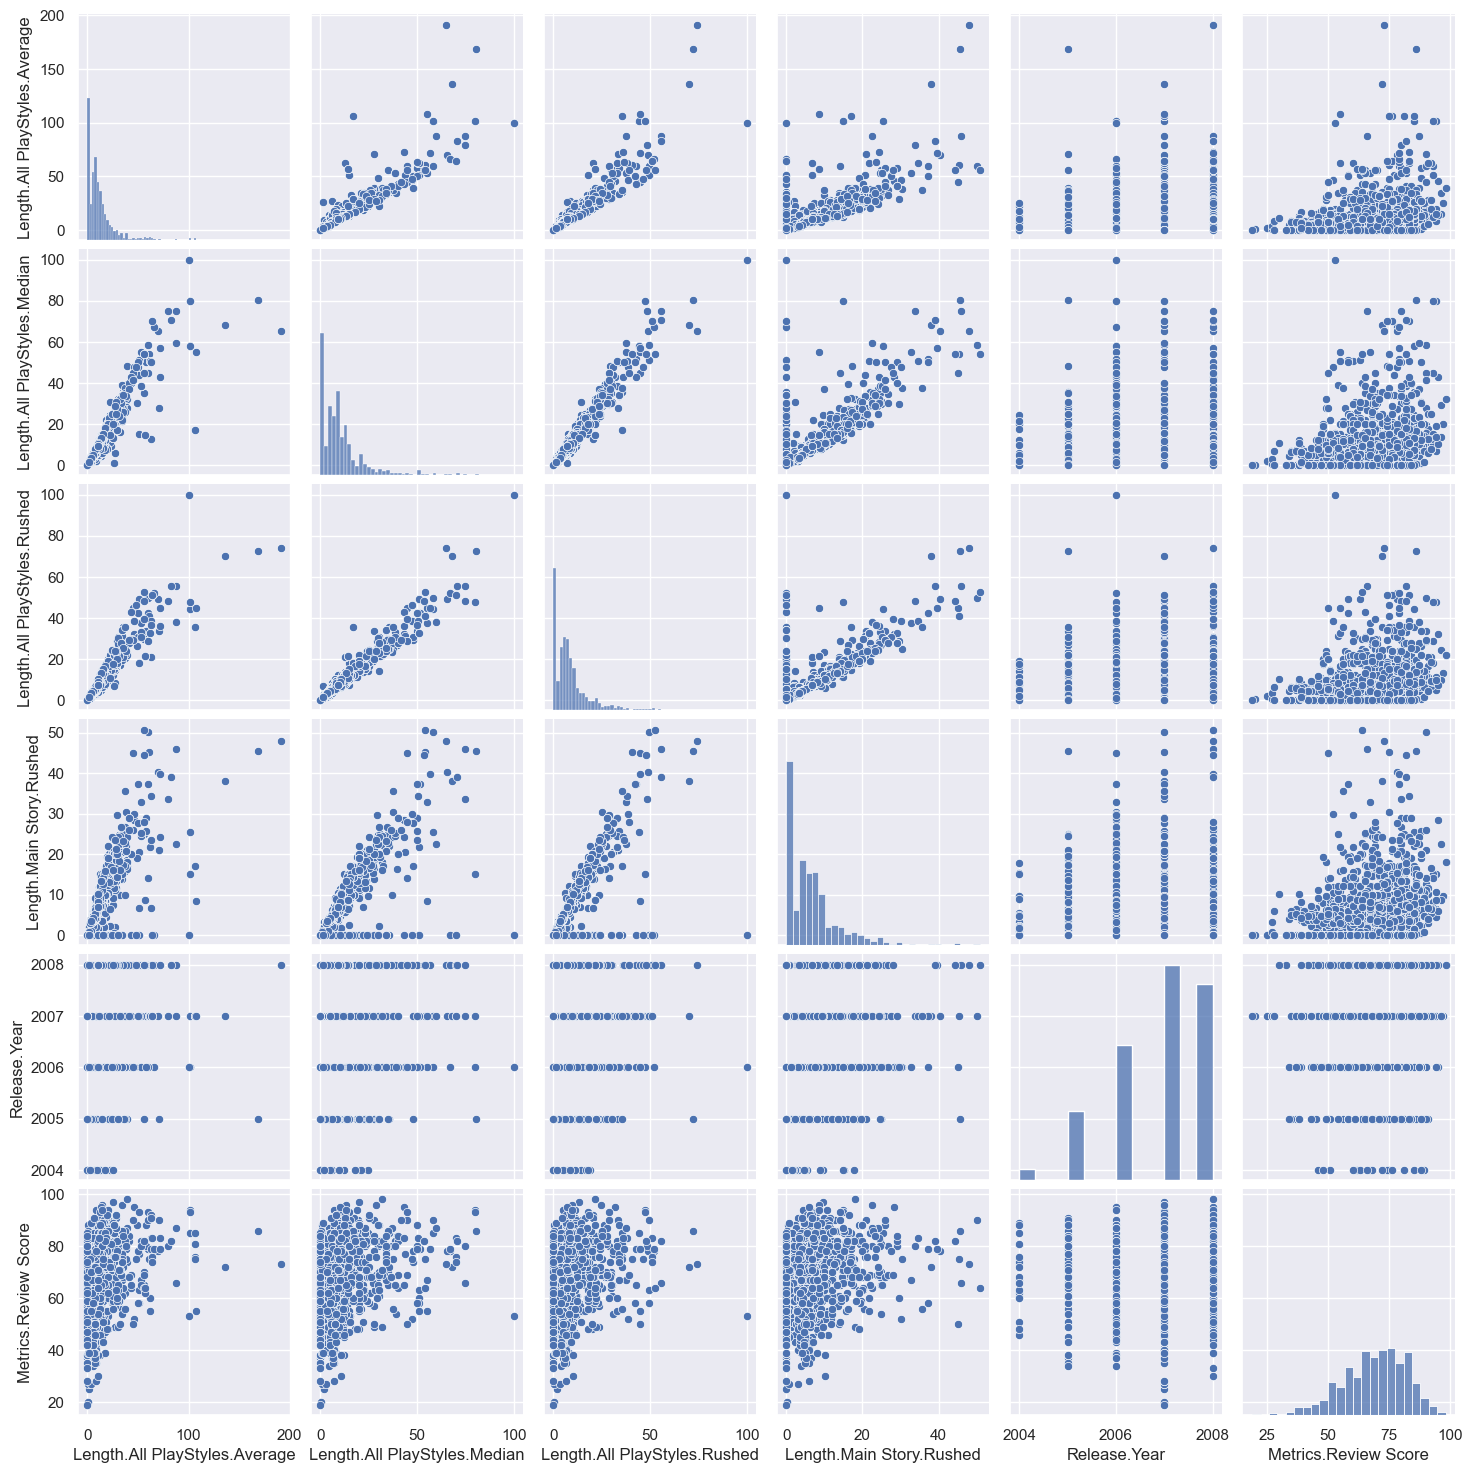

In [539]:
sns.pairplot(df)
plt.show()

In [540]:
df = df.rename(columns={
    "Metrics.Review Score": "Metrics_Review_Score",
    "Length.All PlayStyles.Average": "PlayStyles_Average",
    "Length.All PlayStyles.Median": "PlayStyles_Median",
    "Length.All PlayStyles.Rushed": "PlayStyles_Rushed",
    "Length.Main Story.Rushed": "Main_Story_Rushed",
    "Release.Year": "Release_Year"
})
df.head()

,PlayStyles_Average,PlayStyles_Median,PlayStyles_Rushed,Main_Story_Rushed,Release_Year,Metrics_Review_Score
0,22.716667,24.483333,14.300000,9.700000,2004,85
1,10.100000,10.000000,9.516667,9.583333,2004,89
2,4.566667,2.500000,2.266667,1.433333,2004,81
3,0.000000,0.000000,0.000000,0.000000,2004,81
4,13.250000,10.000000,7.066667,5.333333,2004,61


In [541]:
formula = "Metrics_Review_Score~PlayStyles_Average+PlayStyles_Median+PlayStyles_Rushed+Main_Story_Rushed+Release_Year"
full_model = smf.ols(formula= formula, data=df).fit()
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Metrics_Review_Score   R-squared:                       0.099
Model:                              OLS   Adj. R-squared:                  0.096
Method:                   Least Squares   F-statistic:                     26.57
Date:                  Thu, 03 Apr 2025   Prob (F-statistic):           1.53e-25
Time:                          03:36:50   Log-Likelihood:                -4749.4
No. Observations:                  1209   AIC:                             9511.
Df Residuals:                      1203   BIC:                             9541.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            769.5668    678.433      1.134      0.257    -561.476    2100.610
PlayStyles_Average     0.2664      0.054      4.976      0.000       0.161       0.371
PlayStyles_Median      0.5826      0.114      5.110      0.000       0.359       0.806
PlayStyles_Rushed     -0.9213      0.165     -5.591      0.000      -1.245      -0.598
Main_Story_Rushed      0.1930      0.072      2.671      0.008       0.051       0.335
Release_Year          -0.3506      0.338     -1.037      0.300      -1.014       0.313
==============================================================================
Omnibus:                       62.068   Durbin-Watson:                   1.645
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.521
Skew:                          -0.585   Prob(JB):                     4.86e-16
Kurtosis:                       3.171   Cond. No.                     3.84e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.84e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

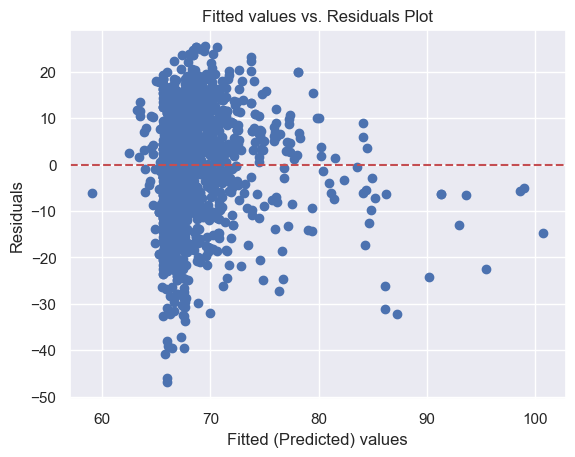

In [542]:
plt.scatter(full_model.fittedvalues, full_model.resid)
plt.axhline(y=0, color='r', linestyle = '--')
plt.ylabel('Residuals')
plt.xlabel('Fitted (Predicted) values')
plt.title('Fitted values vs. Residuals Plot')
plt.show()

#### Apply log transformation to time-based variables

In [543]:
df["log_PlayStyles_Average"] = np.log(df["PlayStyles_Average"] + 1)
df["log_PlayStyles_Median"] = np.log(df["PlayStyles_Median"] + 1)
df["log_PlayStyles_Rushed"] = np.log(df["PlayStyles_Rushed"] + 1)
df["log_Main_Story_Rushed"] = np.log(df["Main_Story_Rushed"] + 1)
df.describe()

,PlayStyles_Average,PlayStyles_Median,PlayStyles_Rushed,Main_Story_Rushed,Release_Year,Metrics_Review_Score,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed
count,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000
mean,13.330673,11.048125,9.239509,6.884478,2006.820513,68.821340,2.050404,1.943243,1.824090,1.573325
std,17.577428,12.838714,10.545850,7.610975,1.050879,12.965166,1.219566,1.156736,1.096265,1.080809
min,0.000000,0.000000,0.000000,0.000000,2004.000000,19.000000,0.000000,0.000000,0.000000,0.000000
25%,3.550000,3.000000,2.600000,0.000000,2006.000000,60.000000,1.515127,1.386294,1.280934,0.000000
50%,8.833333,8.000000,6.700000,5.333333,2007.000000,70.000000,2.285778,2.197225,2.041220,1.845827
75%,15.983333,13.716667,11.333333,9.300000,2008.000000,79.000000,2.832232,2.688981,2.512306,2.332144
max,191.250000,100.000000,100.000000,50.783333,2008.000000,98.000000,5.258797,4.615121,4.615121,3.947068


In [544]:
log_formula = ("Metrics_Review_Score ~ log_PlayStyles_Average + log_PlayStyles_Median + log_PlayStyles_Rushed + log_Main_Story_Rushed + Release_Year")
log_full_model = smf.ols(formula=log_formula, data=df).fit()
log_full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Metrics_Review_Score   R-squared:                       0.134
Model:                              OLS   Adj. R-squared:                  0.130
Method:                   Least Squares   F-statistic:                     37.15
Date:                  Thu, 03 Apr 2025   Prob (F-statistic):           1.71e-35
Time:                          03:36:51   Log-Likelihood:                -4726.0
No. Observations:                  1209   AIC:                             9464.
Df Residuals:                      1203   BIC:                             9495.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                807.3077    665.692      1.213      0.225    -498.739    2113.354
log_PlayStyles_Average    12.7391      1.874      6.799      0.000       9.063      16.415
log_PlayStyles_Median      8.8887      2.427      3.663      0.000       4.128      13.650
log_PlayStyles_Rushed    -20.5126      2.943     -6.969      0.000     -26.287     -14.738
log_Main_Story_Rushed      0.6240      0.564      1.107      0.269      -0.482       1.730
Release_Year              -0.3715      0.332     -1.120      0.263      -1.022       0.279
==============================================================================
Omnibus:                       72.256   Durbin-Watson:                   1.711
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.968
Skew:                          -0.637   Prob(JB):                     5.84e-19
Kurtosis:                       3.211   Cond. No.                     3.84e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.84e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

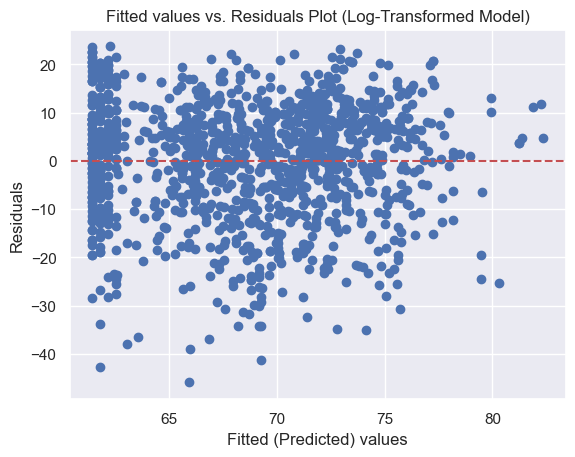

In [545]:
plt.scatter(log_full_model.fittedvalues, log_full_model.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.ylabel('Residuals')
plt.xlabel('Fitted (Predicted) values')
plt.title('Fitted values vs. Residuals Plot (Log-Transformed Model)')
plt.show()

### Result:
The log transformation brought the model closer to satisfying the linearity assumption, as observed in the improved residuals vs. fitted values plot. By conceptually dividing the fitted values axis into a series of small-width boxes from left to right, we see that the residuals within each box are roughly evenly distributed above and below zero. This balanced pattern indicates that there is a linear relationship between the explanatory variables and the response variable. Therefore, a linear regression model is a suitable type of model for this dataset.

## 5. Predictive Models

#### Train-Test Split:

In [546]:
log_columns = [
    "log_PlayStyles_Average",
    "log_PlayStyles_Median",
    "log_PlayStyles_Rushed",
    "log_Main_Story_Rushed",
    "Release_Year",
    "Metrics_Review_Score"
]
df_train, df_test = train_test_split(df[log_columns], test_size = 0.2, random_state = 207)
df_train.head()

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year,Metrics_Review_Score
460,3.253599,3.044522,2.775709,2.484907,2007,80
1045,2.867899,2.867899,2.766319,0.000000,2008,78
844,2.687847,2.397895,2.116256,1.941137,2008,95
942,2.575154,2.397895,2.247777,2.087740,2008,82
329,3.564355,3.168985,3.096331,2.701361,2006,61


In [547]:
df_test.head()

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year,Metrics_Review_Score
355,0.000000,0.000000,0.000000,0.000000,2006,38
380,2.317474,2.197225,1.931521,1.953028,2006,58
1038,2.625876,2.537657,2.494582,2.564949,2008,54
1165,1.635755,1.609438,1.529673,1.500367,2008,60
1167,0.000000,0.000000,0.000000,0.000000,2008,65


In [548]:
X_train = df_train.drop(["Metrics_Review_Score"], axis=1)
y_train = df_train["Metrics_Review_Score"]
X_test = df_test.drop(["Metrics_Review_Score"], axis=1)
y_test = df_test["Metrics_Review_Score"]

In [549]:
scaler_training = StandardScaler()

scaler_expl_vars = scaler_training.fit_transform(X_train) 

X_train = pd.DataFrame(scaler_expl_vars, columns = X_train.columns, index=X_train.index)
X_train.head()

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year
460,0.989279,0.953741,0.866969,0.845143,0.159916
1045,0.670790,0.800038,0.858351,-1.468778,1.120405
844,0.522115,0.391028,0.261687,0.338790,1.120405
942,0.429059,0.391028,0.382404,0.475306,1.120405
329,1.245882,1.062052,1.161254,1.046704,-0.800573


In [550]:
X_test_scaled = scaler_training.transform(X_test)

X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_test.head()

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year
355,-1.697349,-1.695689,-1.680728,-1.468778,-0.800573
380,0.216282,0.216398,0.092128,0.349863,-0.800573
1038,0.470942,0.512653,0.608935,0.919678,1.120405
1165,-0.346640,-0.295110,-0.276711,-0.071651,1.120405
1167,-1.697349,-1.695689,-1.680728,-1.468778,1.120405


### 5.1. Non-Regularized Linear Regression Full Model

In [551]:
lin_reg_mod = LinearRegression()
lin_reg_mod.fit(X_train,y_train)

df_slopes = pd.DataFrame(lin_reg_mod.coef_.T, columns = ["lin_reg_mod"], index = X_train.columns)
df_slopes.sort_values(by = ['lin_reg_mod'])

,lin_reg_mod
log_PlayStyles_Rushed,-24.266524
Release_Year,-0.565048
log_Main_Story_Rushed,0.949479
log_PlayStyles_Median,12.876865
log_PlayStyles_Average,14.614809


In [552]:
lin_reg_mod_test_r2 = lin_reg_mod.score(X_test,y_test)
lin_reg_mod_test_r2

0.07347963600180185

In [553]:
untransformed_columns = [
    "PlayStyles_Average",
    "PlayStyles_Median",
    "PlayStyles_Rushed",
    "Main_Story_Rushed",
    "Release_Year",
    "Metrics_Review_Score"
]
df_train_untrans, df_test_untrans = train_test_split(df[untransformed_columns], test_size=0.2, random_state=207)
X_train_untrans = df_train_untrans.drop("Metrics_Review_Score", axis=1)
y_train_untrans = df_train_untrans["Metrics_Review_Score"]
X_test_untrans = df_test_untrans.drop("Metrics_Review_Score", axis=1)
y_test_untrans = df_test_untrans["Metrics_Review_Score"]

In [554]:
scaler_untrans = StandardScaler()
X_train_untrans_scaled = pd.DataFrame(scaler_untrans.fit_transform(X_train_untrans), columns=X_train_untrans.columns, index=X_train_untrans.index)
X_train_untrans_scaled.head()

,PlayStyles_Average,PlayStyles_Median,PlayStyles_Rushed,Main_Story_Rushed,Release_Year
460,0.660978,0.692364,0.544352,0.546262,0.159916
1045,0.186665,0.428840,0.530207,-0.909534,1.120405
844,0.020608,-0.082705,-0.186483,-0.119875,1.120405
942,-0.069101,-0.082705,-0.076465,0.025705,1.120405
329,1.201141,0.908091,1.116447,0.930063,-0.800573


In [555]:
X_test_untrans_scaled = pd.DataFrame(scaler_untrans.transform(X_test_untrans), columns=X_test_untrans.columns, index=X_test_untrans.index)
X_test_untrans_scaled.head()

,PlayStyles_Average,PlayStyles_Median,PlayStyles_Rushed,Main_Story_Rushed,Release_Year
355,-0.763869,-0.857773,-0.874883,-0.909534,-0.800573
380,-0.239930,-0.237718,-0.318505,-0.108846,-0.800573
1038,-0.029973,0.045182,0.173434,0.678608,1.120405
1165,-0.527190,-0.547746,-0.533827,-0.448532,1.120405
1167,-0.763869,-0.857773,-0.874883,-0.909534,1.120405


In [556]:
from sklearn.metrics import r2_score

model_untrans = LinearRegression()
model_untrans.fit(X_train_untrans_scaled, y_train_untrans)

y_pred_untrans = model_untrans.predict(X_test_untrans_scaled)
r2_untrans = r2_score(y_test_untrans, y_pred_untrans)
r2_untrans

0.05224202858947735

The log-transformed model performs better because its test R² is higher than the model using untransformed variables, indicating improved predictive accuracy.

### 5.2. Non-Regularized Linear Regression Full Model with Interaction Terms

Since all five of my explanatory variables are numerical, and there are no categorical variables to create meaningful interaction terms with, I chose to omit the interaction component in this model.

In [557]:
log_features = [
    "log_PlayStyles_Average",
    "log_PlayStyles_Median",
    "log_PlayStyles_Rushed",
    "log_Main_Story_Rushed",
    "Release_Year"
]
df[log_features].corr()


,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year
log_PlayStyles_Average,1.000000,0.983329,0.987669,0.814514,0.031937
log_PlayStyles_Median,0.983329,1.000000,0.991775,0.817037,0.025467
log_PlayStyles_Rushed,0.987669,0.991775,1.000000,0.809267,0.025715
log_Main_Story_Rushed,0.814514,0.817037,0.809267,1.000000,0.046215
Release_Year,0.031937,0.025467,0.025715,0.046215,1.000000


### 5.3. Feature Selection 

I use Elastic Net regularization model. 

1. In a for loop, iterate through a series of $\lambda$ values that go from 0.001 to 10.
2. Find the lambda value in Elastic Net regularization model which will yield the HIGHEST possible test R^2. 

In [558]:
from sklearn.linear_model import ElasticNet

lambda_values = np.arange(0.001, 10.001, 0.1)
r2_list = []

for lam in lambda_values:
    net = ElasticNet(alpha=lam, l1_ratio=0.8, random_state=207, max_iter=10000)
    net.fit(X_train, y_train)
    y_pred = net.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    r2_list.append(test_r2)
result = pd.DataFrame({"Lambda": lambda_values,"Test_R2": r2_list })
result



,Lambda,Test_R2
0,0.001,0.074420
1,0.101,0.066897
2,0.201,0.061526
3,0.301,0.061712
4,0.401,0.062132
...,...,...
95,9.501,-0.000678
96,9.601,-0.000678
97,9.701,-0.000678
98,9.801,-0.000678


In [559]:
higest_test_r = result.sort_values(by="Test_R2", ascending=False).iloc[0]
higest_test_r

Lambda     0.00100
Test_R2    0.07442
Name: 0, dtype: float64

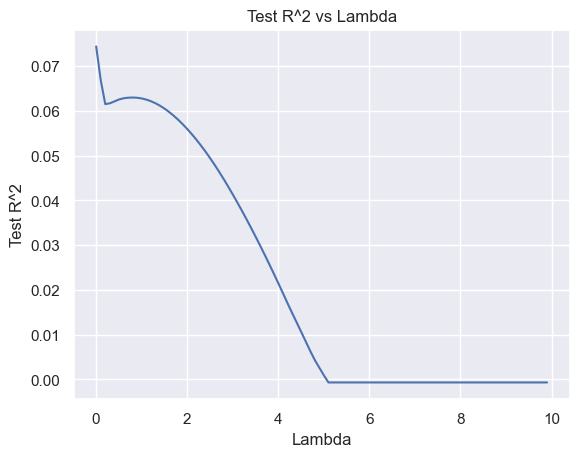

In [560]:
plt.plot(result["Lambda"], result["Test_R2"])
plt.title("Test R^2 vs Lambda")
plt.xlabel("Lambda")
plt.ylabel("Test R^2")
plt.show()

#### Result:
The Best Model which has the highest Test R^2 is when the lambda is euqal to 0.00100.

## 6. Best Model Discussion

#### 1. Equation for the model that had the **Highest** test R^2 (*Original Variable Name*):

$$
\hat{Metrics.Review Score}  = 68.75284384694939\\

+ 14.324208 * Length.All PlayStyles.Average \\ 

+ 12.406413 * Length.All PlayStyles.Median	 \\ 

- 23.523347 * Length.All PlayStyles.Rushed \\

+ 0.969089 * Length.Main Story.Rushed \\

- 0.560811 * Release.Year \\
$$

#### 2. Test Dataset Fit:
The best Elastic Net model achieves a test R^2 of 0.075, indicating that it explains approximately 7.5% of the variability in video game review scores. This reflects a weak overall fit and suggests that other, unmeasured factors may have a stronger influence on review scores than the variables included in the model.

#### 3. Overfitting Explanatory Variables:
The results from the Elastic Net model suggest that some of the original explanatory variables were likely overfitting the model. Specifically, `log_Main_Story_Rushed` (*`Length.Main Story.Rushed`*) and `Release_Year` (*`Release.Year`*) had very small coefficients in the final model, indicating that they contributed little to the prediction and were likely reduced in importance to prevent overfitting.

In [561]:
best_model = ElasticNet(alpha=0.00100, l1_ratio=0.8, random_state=207, max_iter=1000)
best_model.fit(X_train, y_train)

ElasticNet(alpha=0.001, l1_ratio=0.8, random_state=207)

In [562]:
intercept = best_model.intercept_
intercept

np.float64(68.75284384694939)

In [563]:
model_slope = pd.DataFrame(best_model.coef_, index=X_train.columns, columns=["ElasticNet Slope"])
model_slope

,ElasticNet Slope
log_PlayStyles_Average,14.324208
log_PlayStyles_Median,12.406413
log_PlayStyles_Rushed,-23.523347
log_Main_Story_Rushed,0.969089
Release_Year,-0.560811


#### 4. Multicollinearity:

 The remaining explanatory variables in the model (`log_PlayStyles_Average`, `log_PlayStyles_Median`, and `log_PlayStyles_Rushed`) exhibit strong multicollinearity, as all pairwise correlations are greater than 0.7. Therefore, the model has the issue with the multicollinearity.

In [564]:
selection_columns = df[[
    "log_PlayStyles_Average",
    "log_PlayStyles_Median",
    "log_PlayStyles_Rushed",
    "log_Main_Story_Rushed",
    "Release_Year"
]].corr()

selection_columns

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed,log_Main_Story_Rushed,Release_Year
log_PlayStyles_Average,1.000000,0.983329,0.987669,0.814514,0.031937
log_PlayStyles_Median,0.983329,1.000000,0.991775,0.817037,0.025467
log_PlayStyles_Rushed,0.987669,0.991775,1.000000,0.809267,0.025715
log_Main_Story_Rushed,0.814514,0.817037,0.809267,1.000000,0.046215
Release_Year,0.031937,0.025467,0.025715,0.046215,1.000000


In [565]:
selected_columns = [
    "log_PlayStyles_Average",
    "log_PlayStyles_Median",
    "log_PlayStyles_Rushed"
]

correlation_matrix = df[selected_columns].corr()
correlation_matrix

,log_PlayStyles_Average,log_PlayStyles_Median,log_PlayStyles_Rushed
log_PlayStyles_Average,1.000000,0.983329,0.987669
log_PlayStyles_Median,0.983329,1.000000,0.991775
log_PlayStyles_Rushed,0.987669,0.991775,1.000000


#### 5. Slope Interpretations
Since the explanatory variables were standardized, we can interpret the slope magnitudes to assess the relative importance of each variable in predicting review scores. Based on the slope values, the most important explanatory variable is `log_PlayStyles_Average`	(*`Length.All PlayStyles.Average`*), as it contributes the most predictive power to the model. This is followed by `log_PlayStyles_Median` (*`Length.All PlayStyles.Median`*) and `log_Main_Story_Rushed`	(*`Length.Main Story.Rushed`*), which also show positive relationships with the response variable, although their influence is comparatively smaller.

## 7. Conclusion

### Recommendation:
I would not recommend using the best model in its current form. The model's test R^2 is only 0.075, meaning it explains just 7.5% of the variation in video game review scores. This indicates weak predictive performance and suggests that the model does not generalize well to new data. Additionally, the remaining explanatory variables exhibit strong multicollinearity, which can make the model unstable and the interpretation of individual coefficients less reliable.

### Shortcomings/Caveats:
I cannot say with certainty that the chosen best model yields the highest possible test R^2 from this dataset. This is because I only explored a single regularization method — Elastic Net — when a more complete analysis would also examine other techniques such as LASSO and Ridge Regression. Furthermore, the key explanatory variables (log_PlayStyles_Average, Median, Rushed) are highly correlated, with correlation coefficients above 0.7, which may result in multicollinearity and unstable slope estimates. Although I applied filtering to remove some outliers, these may still impact correlation strength and regression results. These limitations should be considered when interpreting the model's accuracy or applying its predictions in decision-making.

### Future Work:
In future analyses, I plan to explore additional feature selection methods, such as Backward Elimination and Forward Selection Algorithms. I will also test other regularization approaches, including LASSO and Ridge Regression, since Elastic Net may not be the most optimal choice for this dataset. Beyond model tuning, incorporating new and more informative features — such as player satisfaction scores, critic ratings, game genre, or platform — could significantly improve model performance. These steps will provide a more robust and accurate predictive model.